![](../../.bridgce_stellar.png)

# Stellar Fingerprints


In [80]:
# ---------------------------------------------------------------------------
# Set this to the local path of your bridgce2026-stellar-nucleosynthesis
# clone. Every data path in this notebook is built from LOCAL_ROOT below --
# this is the only line you should need to change if you've moved the
# notebook, or are running it somewhere other than its usual place in the
# repo (resources/labs/).
# ---------------------------------------------------------------------------
from pathlib import Path

LOCAL_ROOT = Path("../..")   # default: repo root, two levels up from resources/labs/
# LOCAL_ROOT = Path("/absolute/path/to/bridgce2026-stellar-nucleosynthesis")

DATA_dir = LOCAL_ROOT / "resources" / "labs" / "data"

In [81]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import pandas as pd
import re

## Stellar yields

**Yield** ($Y_i$): the total mass of a species $i$ (an isotope or element) carried out of a star by its ejecta -- a wind, or an explosion:

$$
Y_i = X_i \, M_{\rm ejecta}
$$

where $X_i$ is the mass fraction of species $i$ in the ejecta and $M_{\rm ejecta}$ is the total ejected mass. This is sometimes called the "final" or "gross" yield: it's what you'd actually measure from the ejected material, and it includes whatever species $i$ the star was already born with, not just what it made.

**Net yield** ($Y_i^{\rm net}$): the mass of species $i$ the star actually *synthesised* (or destroyed), found by subtracting off however much of it the star started with:

$$
Y_i^{\rm net} = Y_i - Y_i^{\rm initial} = M_{\rm ejecta}\left(X_i^{\rm ejecta} - X_i^{\rm initial}\right)
$$

A positive net yield means the star made more of that species than it started with (net production); negative means net destruction. Net yield is what you want when asking "what did this star contribute to Galactic chemical evolution?" -- yield alone conflates that with whatever the star inherited at birth.

> Not every table in this lab gives you both. Only the Cinquegrana+ Type II grid has the pre-explosion composition needed to compute a genuine net yield (columns `"initial [Msun]"`, `"final [Msun]"`, `"net yield [Msun]"`). For the rest, you only get one column, and it isn't always the same *kind* of yield: the ecSN (Wanajo+ 2009), Type Ia (Leung & Nomoto 2018) and metal-poor AGB (Karakas & Lugaro 2016) tables publish the raw ejecta mass (yield, not net); the metal-rich AGB table (Cinquegrana & Karakas 2022) publishes an already-computed net yield. Check which one you're looking at before comparing across sources.

The yields used in this lab are from Cinquegrana, Heger & Karakas (2025, unpublished Type II grid), Wanajo et al. (2009, ecSN), Leung & Nomoto (2018, Type Ia), and Karakas & Lugaro (2016) / Cinquegrana & Karakas (2022) (AGB). The two CEMP-s/r stars (Ivans et al. 2005; Sneden et al. 2003) aren't yields at all -- they're observed atmospheric abundance ratios, [X/Fe], not stellar ejecta masses.

In [83]:
# YOU CAN IGNORE the following code block -- it just sets up some utility functions for the notebook.

ELEMENT_Z = {sym: z for z, sym in enumerate("""
H He Li Be B C N O F Ne Na Mg Al Si P S Cl Ar K Ca Sc Ti V Cr Mn Fe Co Ni Cu Zn
Ga Ge As Se Br Kr Rb Sr Y Zr Nb Mo Tc Ru Rh Pd Ag Cd In Sn Sb Te I Xe Cs Ba La Ce
Pr Nd Pm Sm Eu Gd Tb Dy Ho Er Tm Yb Lu Hf Ta W Re Os Ir Pt Au Hg Tl Pb Bi Po At Rn
Fr Ra Ac Th Pa U
""".split(), start=1)}

def resolve_Z(x):
    """Accept an atomic number or an element symbol ('Fe', 'Ba', ...) and return the atomic number."""
    return ELEMENT_Z[x] if isinstance(x, str) else x

def isotopes_to_elements(series):
    """Sum an isotope-labelled Series ('56Fe', 'Fe56', ...) to one value per element."""
    symbols = [re.sub(r"\d+", "", str(i)) for i in series.index]
    return series.groupby(symbols).sum()

def elemental_table(series, name="yield [Msun]"):
    """Collapse an isotope- or element-labelled Series to one row per element, with its
    atomic number Z. Isotope labels are summed to their element first; already-elemental
    labels ('Fe', 'Zr', as in the Cinquegrana+ grid) pass straight through unchanged."""
    idx = series.index.astype(str)
    if idx.str.match(r"^\d").all():
        series = isotopes_to_elements(series)
    table = series.rename(name).to_frame()
    table["Z"] = table.index.map(ELEMENT_Z)
    return table.dropna(subset=["Z"]).astype({"Z": int}).sort_values("Z")

def plot_yield_vs_Z(table, ycol, title=None, logy=False, symlog=False, ax=None, xlim=None, label=None, color=None):
    """xlim: optional (low, high) bound on atomic number, each given as an int or an element
    symbol -- e.g. xlim=("Ga", "Zr"), xlim=(31, 40), or a mix like xlim=("Ga", 40).
    label: optional legend label, for overlaying multiple sources on the same ax.
    color: optional curve colour (any matplotlib colour spec); default lets matplotlib cycle."""
    if xlim is not None:
        lo, hi = resolve_Z(xlim[0]), resolve_Z(xlim[1])
        table = table[(table["Z"] >= lo) & (table["Z"] <= hi)]
    ax = ax or plt.gca()
    ax.plot(table["Z"], table[ycol], marker="o", lw=1, label=label, color=color)
    if symlog:
        ax.set_yscale("symlog", linthresh=1e-8)
        ax.axhline(0, color="0.7", lw=0.8, zorder=0)
    elif logy:
        ax.set_yscale("log")
    ax.set_xticks(table["Z"])
    ax.set_xticklabels(table.index, rotation=90, fontsize=6)
    ax.set_xlabel("atomic number Z")
    ax.set_ylabel(ycol)
    ax.set_title(title)
    return ax

POP_dir = DATA_dir / "population_yields"
_masses = pd.read_csv(POP_dir / "masses.csv")
Z_LABEL = {0: "z0p00714", 1: "z0p00714", 2: "z0p01", 3: "z0p016", 4: "z0p025", 5: "z0p0357",
           6: "z0p05", 7: "z0p0714", 8: "z0p12", 10: "z0p25", 11: "z0p357",
           12: "z0p5", 13: "z0p75", 14: "z01", 15: "z02", 16: "z03", 17: "z04", 18: "z05"}

def match_ejecta_mass(z_init, z_grid, target_mass):
    """Nearest-neighbour match into masses.csv, which stores the exact (Z, M) grid used --
    total ejecta mass (M_ZAMS - M_remnant) for that specific model, in Msun."""
    zs = _masses["z"].unique()
    zbest = zs[np.argmin(np.abs(zs - z_grid[z_init]))]
    sub = _masses[_masses["z"] == zbest]
    mbest = sub["m"].values[np.argmin(np.abs(sub["m"].values - target_mass))]
    return sub[sub["m"] == mbest].iloc[0]["yd_mass"]

def load_initial_massfrac(z_init):
    df = pd.read_csv(POP_dir / "initia_abunds" / f"{Z_LABEL[z_init]}.csv")
    return isotopes_to_elements(df.iloc[0])

CINQUEGRANA_dir = DATA_dir / "yields_oct2025"
_cinquegrana_used = pd.read_csv(CINQUEGRANA_dir / "cinquegrana_typeII_yields.csv")
Z_GRID = [0.007, 0.00714, 0.01, 0.016, 0.025, 0.036, 0.05, 0.0714, 0.12, 0.16, 0.25, 0.36, 0.50, 0.75, 1, 2, 3, 4, 5]

def cinquegrana_log_abundances(z_init, m_init):
    """[X] = log10(X_ejecta / X_solar) at one (Z_init, M_init) grid point, for every element
    the vendored extract provides. Only (Z_init, M_init) pairs already saved in
    cinquegrana_typeII_yields.csv are available -- see the NOTE above cinquegrana_yields()."""
    match = _cinquegrana_used[(_cinquegrana_used.Z_init == z_init) &
                               (_cinquegrana_used.M_init == m_init)].iloc[0]
    return match.drop(["Z_init", "M_init"])

def cinquegrana_yields(z_init, m_init=20, target_mass=15.125):
    """Initial, final (ejecta) and net-yield elemental masses [Msun] at one grid point.
    final = 10^[X] * X_solar * M_ejecta; initial = X_init(Z) * M_ejecta; net = final - initial.
    NOTE: only z_init in {12, 16} (both at m_init=20) are available -- see CINQUEGRANA_dir above."""
    log_X = cinquegrana_log_abundances(z_init, m_init)
    M_ej = match_ejecta_mass(z_init, Z_GRID, target_mass)
    X_solar = load_initial_massfrac(14)  # Z_init=14 -> Z=1 Zsun -> solar reference
    X_init = load_initial_massfrac(z_init)
    elems = log_X.index
    final = (10 ** log_X) * X_solar.reindex(elems).fillna(0) * M_ej
    initial = X_init.reindex(elems).fillna(0) * M_ej
    table = pd.DataFrame({"initial [Msun]": initial, "final [Msun]": final,
                           "net yield [Msun]": final - initial})
    table["Z"] = table.index.map(ELEMENT_Z)
    return table.dropna(subset=["Z"]).astype({"Z": int}).sort_values("Z"), M_ej

LITERATURE_dir = DATA_dir / "literature"

# SAGB ec-SN: Wanajo, Nomoto, Janka, Kitaura & Muller 2009, ApJ 695, 208, model ST -- a 1D
# neutrino-driven explosion of an 8.8 Msun ONeMg core (the collapse-to-neutron-star channel

wanajo_df = pd.read_csv(LITERATURE_dir / "wanajo2009_ecsn.dat", sep=r"\s+", comment="#")
wanajo_df = wanajo_df.set_index("isotope")

abund_ecsn = wanajo_df["ST"]

table_ecsn = elemental_table(abund_ecsn)

# metal-poor / metal-rich type Ia: Leung & Nomoto 2018, ApJ 861, 143, the rho_c=3e9 g/cm^3,
# c3-flame, C/O=1 near-Chandrasekhar deflagration series (models 300-Z-c3-1), which they ran at
# seven Z. We use Z=0.5 and Z=3 Zsun below -- the same two metallicities as the Type II cells
# above, so all four SN clues are directly comparable at like-for-like [Fe/H]. 
leung_df = pd.read_csv(LITERATURE_dir / "leung_nomoto2018_typeIa.dat", sep=r"\s+", comment="#")
leung_df = leung_df[leung_df["radioactive"] == 0].set_index("isotope")  # final, fully-decayed yields

abund_ia_mp = leung_df["Z0p5"]
table_ia_mp = elemental_table(abund_ia_mp)

abund_ia_mr = leung_df["Z3"]
table_ia_mr = elemental_table(abund_ia_mr)

KLC25_dir = DATA_dir / "klc25"
Z_TO_ELEMENT = {z: sym for sym, z in ELEMENT_Z.items()}

# IMS AGB, metal-poor: Karakas & Lugaro 2016, ApJ 825, 26, Z=0.007, M=6 Msun. Columns are
# [mass, Zini, mrem, el, Z, yield]
def load_kl16_elements(z_str, mass, zmax=26):
    df = pd.read_csv(KLC25_dir / f"KL16_z{z_str}.dat", sep=r"\s+", header=None,
                      names=["mass", "Zini", "mrem", "el", "Z", "yield [Msun]"])
    sub = df[(df["mass"] == mass) & (df["Z"] <= zmax)].copy()
    sub["symbol"] = sub["Z"].map(Z_TO_ELEMENT)
    return sub.set_index("symbol")[["Z", "yield [Msun]"]].sort_values("Z")

table_agb_mp = load_kl16_elements("007", 6.00)
# display(table_agb_mp)

# IMS AGB, metal-rich: Cinquegrana & Karakas 2022, MNRAS 510, 1557, Z=0.04, M=6 Msun.

def ck22_symbol(el):
    if el in ("p", "d"):
        return "H"
    return re.match(r"[a-zA-Z]+", el).group(0).capitalize()

def load_ck22_elements(z_str, mass, zmax=26):
    df = pd.read_csv(KLC25_dir / f"CK22_z{z_str}.dat", sep=r"\s+", header=None,
                      names=["mass", "c2", "c3", "el", "A", "yield [Msun]"])
    sub = df[(df["mass"] == mass) & (~df["el"].isin(["g", "n"]))].copy()
    sub["symbol"] = sub["el"].map(ck22_symbol)
    out = sub.groupby("symbol")["yield [Msun]"].sum().to_frame()
    out["Z"] = out.index.map(ELEMENT_Z)
    return out.dropna(subset=["Z"]).astype({"Z": int}).query("Z <= @zmax").sort_values("Z")

table_agb_mr = load_ck22_elements("04", 6.00)
# display(table_agb_mr)

def load_star_abundances(filename):
    df = pd.read_csv(LITERATURE_dir / filename, sep=r"\s+", comment="#")
    return df.set_index("symbol").sort_values("Z")

def plot_star_pattern(table, title=None, ax=None, xlim=None, color="0.4"):
    """xlim: optional (low, high) bound on atomic number, each given as an int or an element
    symbol -- e.g. xlim=("Sr", "Pb"), xlim=(38, 82), or a mix like xlim=("Sr", 82).
    color: colour of the main [X/Fe] curve -- the Ba/Eu highlight dots stay orange/red regardless."""
    if xlim is not None:
        lo, hi = resolve_Z(xlim[0]), resolve_Z(xlim[1])
        table = table[(table["Z"] >= lo) & (table["Z"] <= hi)]
    ax = ax or plt.gca()
    ax.plot(table["Z"], table["[X/Fe]"], marker="o", lw=1, color=color, zorder=1)
    for sym in ("Ba", "Eu"):
        if sym in table.index:
            z, xfe = table.loc[sym, ["Z", "[X/Fe]"]]
            ax.scatter([z], [xfe], s=90, zorder=2, label=f"{sym} [X/Fe]={xfe:+.2f}",
                       color="tab:orange" if sym == "Ba" else "tab:red")
    ax.set_xticks(table["Z"])
    ax.set_xticklabels(table.index, rotation=90, fontsize=6)
    ax.set_xlabel("atomic number Z")
    ax.set_ylabel("[X/Fe]")
    ax.set_title(title)
    ax.legend(fontsize=8)
    return ax

# CEMP-s: CS 29497-030 (Ivans et al. 2005) -- matched against a Goriely & Mowlavi (2000)
# Z=0.001 AGB model and a 1.3 Msun AGB s-process model diluted by a factor of 2.
table_cemps = load_star_abundances("ivans2005_cs29497-030.dat")
# display(table_cemps)

# CEMP-r (r-II): CS 22892-052 (Sneden et al. 2003) -- matched against the scaled solar-system
# r-process-only residual pattern, shifted to match the observed Eu. 
table_cempr = load_star_abundances("sneden2003_cs22892-052.dat")
# display(table_cempr)

## Type II Supernovae: sub-solar vs super-solar metallicity progenitors

> Note: these are non-rotating models.

Q1. Compare the alpha elements (O, Mg, Si, S, Ca) to the odd-Z elements (Na, Al, P, Cl, K, Sc) between the sub-solar and super-solar progenitor. Which group is more sensitive to metallicity, and why?

Q2. Besides the alpha vs odd-Z contrast, one other element group changes markedly with metallicity in the *net* yield -- which one, and does it get stronger or weaker at higher metallicity? Now switch `YIELD_COL` to `"final [Msun]"` and look at Fe (Z=26): does the metallicity trend run the *same* way as it did for the net yield? What does that tell you about the difference between an element's final (observed) ejecta abundance and what the star actually synthesised?

Q3. If these models included rotation, which element group would you expect to be most affected, and why? Would that enhancement be bigger in the sub-solar or the super-solar progenitor?

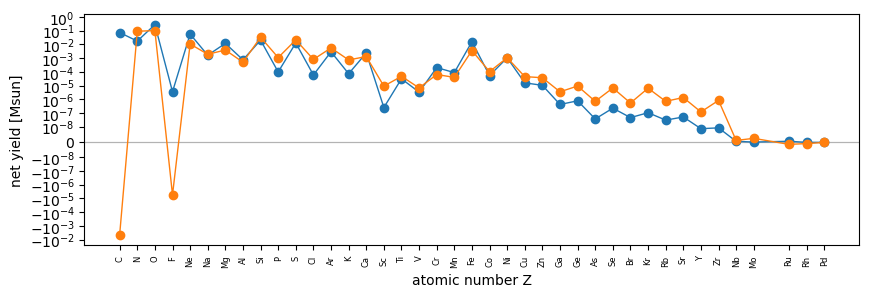

In [84]:
table_mp_II, M_ej_mp_II = cinquegrana_yields(z_init=12)
table_mr_II, M_ej_mr_II = cinquegrana_yields(z_init=16)

YIELD_COL = "net yield [Msun]"
# YIELD_COL = "final [Msun]"

fig, ax = plt.subplots(figsize=(10, 3))
plot_yield_vs_Z(table_mp_II, YIELD_COL, xlim=("C", "Pd"), symlog=True)
plot_yield_vs_Z(table_mr_II, YIELD_COL, xlim=("C", "Pd"), symlog=True)
plt.show()

## EC-SNe vs SNe Type II

Q4. What group of elements diverges the most between the ecSN and the Type II models, and roughly what range in Z does it span?

Q5. Is the process responsible for that divergence explosive or hydrostatic burning? Justify your answer using the ecSN's tiny total ejecta mass and the physical conditions (electron fraction Ye) of its innermost layers.

Q6. Which elements track closely between the ecSN and the Type II models (in *shape*, not absolute mass), and what does that tell you about which burning stage produced them?

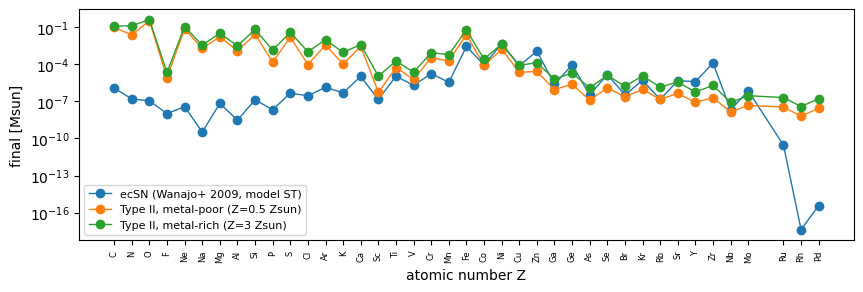

In [85]:
fig, ax = plt.subplots(figsize=(10, 3))
plot_yield_vs_Z(table_ecsn, "yield [Msun]", "SAGB electron-capture SN (Wanajo+ 2009) vs Type II total ejecta",
                logy=True, xlim=("C", "Pd"), label="ecSN (Wanajo+ 2009, model ST)")
plot_yield_vs_Z(table_mp_II, "final [Msun]", xlim=("C", "Pd"), logy=True, ax=ax,
                label="Type II, metal-poor (Z=0.5 Zsun)")
plot_yield_vs_Z(table_mr_II, "final [Msun]", xlim=("C", "Pd"), logy=True, ax=ax,
                label="Type II, metal-rich (Z=3 Zsun)")
ax.legend(fontsize=8)
plt.show()

## SNe Type Ia vs Type II

Q7. Compare the relative amounts of alpha/light elements (O, Ne, Mg) to Fe-peak elements (Cr, Mn, Fe, Ni) between the Type Ia and the Type II model. Which channel is the dominant Galactic source of O, and which is the dominant source of Fe? Why does this distinction matter for how [alpha/Fe] evolves with time in a galaxy?

Q8. Uncomment the `table_ia_mr` line in the cell below to compare the two Type Ia metallicities directly. The Fe (Z=26) peak looks almost identical between them -- does that mean Type Ia yields don't depend on progenitor metallicity at all? Now look one element to the left of Fe, at Mn (Z=25): what do you see, and what does it indicate?

Q9. Unlike the Type II and ecSN models, is there any evidence of s- or r-process (Z>30) production here? What does that tell you about the neutron-richness of a near-Chandrasekhar C/O white dwarf deflagration compared to a massive star's core?

In [ ]:
fig, ax = plt.subplots(figsize=(10, 3))
plot_yield_vs_Z(table_ia_mp, "yield [Msun]", logy=True, label="Type Ia (Z=0.5 Zsun)")
plot_yield_vs_Z(table_ia_mr, "yield [Msun]", logy=True, label="Type Ia (Z=3 Zsun)")
plot_yield_vs_Z(table_mp_II, "final [Msun]", xlim=("C", "Zn"), logy=True, ax=ax,
                label="Type II (Z=0.5 Zsun)")
plt.legend(loc="lower right")
plt.show()

## Intermediate mass AGBs: sub-solar vs super-solar metallicity progenitors

Q10. For the same initial ZAMS mass (6 Msun), the metal-poor (Z=0.007) and metal-rich (Z=0.04) models produce comparable *amounts* of nitrogen (~0.040 Msun vs ~0.030 Msun) -- but look carefully at the *sign* of the carbon yield in each case. What does the combination of the carbon and nitrogen yields (not the nitrogen yield alone) tell you about whether each model is behaving as a "primary" source, freshly manufacturing new C and N, versus a "secondary" one that is mostly just converting existing carbon into nitrogen? Which nucleosynthesis process is doing the converting?

Q11. Do we expect oxygen to be produced significantly in AGB stars? What does the greater O abundance in the metal-poor case indicate (i.e. what process might this be from), and why would that process be weaker -- or reversed -- in the metal-rich case?

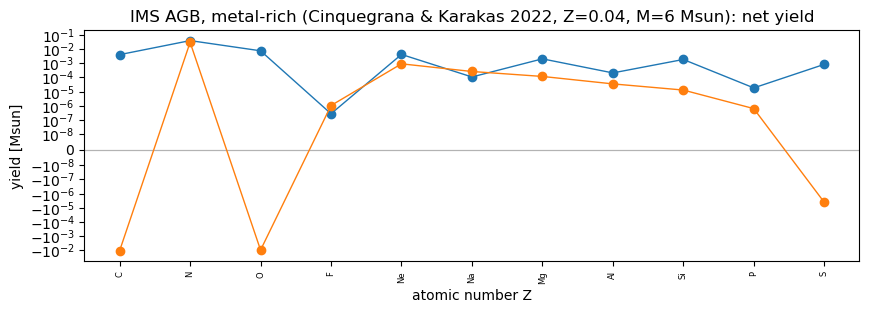

In [63]:
fig, ax = plt.subplots(figsize=(10, 3))
plot_yield_vs_Z(table_agb_mp, "yield [Msun]",
                 "IMS AGB, metal-poor (Karakas & Lugaro 2016, Z=0.007, M=6 Msun): ejecta mass, not net",
                 symlog=True, xlim=("C", "S"))
plot_yield_vs_Z(table_agb_mr, "yield [Msun]",
                 "IMS AGB, metal-rich (Cinquegrana & Karakas 2022, Z=0.04, M=6 Msun): net yield",
                 symlog=True, xlim=("C", "S"))
plt.show()

## Distinguishing between s-process rich AGB material and r-process material from a more extreme source

> **What are CEMP-s / CEMP-r stars?** CEMP = Carbon-Enhanced Metal-Poor: an old, metal-poor star ([Fe/H] << -2) whose atmosphere shows a large carbon excess. The "-s" or "-r" suffix identifies which neutron-capture pattern rides along with that carbon. **CEMP-s** stars carry an s-process pattern, made either by the star itself if it's currently on the AGB ("intrinsic"), or -- far more commonly for the low-mass giants we actually observe -- dumped onto its surface by a more massive AGB companion that has since become a white dwarf ("extrinsic"; see Q13/Q14 below). **CEMP-r** stars instead carry an r-process pattern, generally interpreted not as a binary mass-transfer signature but as a fossil record of Galactic chemical evolution: the star's birth cloud was already enriched by a prior, rare r-process event (e.g. a neutron star merger, or a special class of core-collapse SN) before the star itself ever formed.
>
> Also note: this section works with **real observed stars** (CS 29497-030 and CS 22892-052), unlike every other section in this notebook, which compares *theoretical* model yields.

Q12. Compare the shape of the two curves from Ba (Z=56) through Eu (Z=63) to Pb (Z=82). One star keeps climbing all the way to Pb; the other peaks around the rare earths and turns over before Pb. Which star is which, and what process makes the s-process pattern behave so differently from the r-process one in this region?

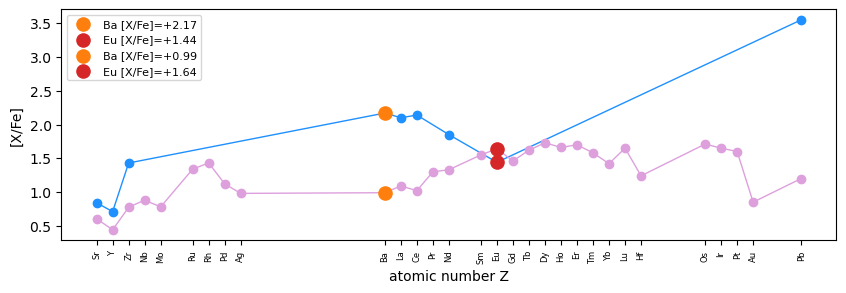

In [69]:
fig, ax = plt.subplots(figsize=(10, 3))
plot_star_pattern(table_cemps, xlim=("Sr", "Pb"), color="dodgerblue")
plot_star_pattern(table_cempr, xlim=("Sr", "Pb"), color="plum")
plt.show()

## Extension Qs

Q13. CEMP-s stars are typically the products of mass transfer from a more massive AGB companion that has since evolved into a white dwarf. The theoretical AGB models used above (Goriely & Mowlavi 2000; Gallino et al.) are single-star models. What might a real binary system change about the s-process pattern we'd actually observe on the surface of the (now low-mass) companion star?

Q14. What element (or isotope) provides a clear indication of whether a CEMP-s star is intrinsic or extrinsic -- i.e. whether the star we're observing is making that material itself right now, or received it from a companion long ago?